# 00. Data Profiling and Master Join
**Objective**: Understand the data before deep analysis, detect quality issues, and build the `master_joined.parquet` file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.autolayout'] = True
PALETTE = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4','#E91E63']
sns.set_palette(PALETTE)

DATA_DIR = '.'
OUTPUT_DIR = './outputs'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)


### Section 1: Setup & Load Tables

In [2]:
products = pd.read_csv(f'{DATA_DIR}/products.csv')
customers = pd.read_csv(f'{DATA_DIR}/customers.csv', parse_dates=['signup_date'])
promotions = pd.read_csv(f'{DATA_DIR}/promotions.csv', parse_dates=['start_date', 'end_date'], dtype={'applicable_category': str})
geography = pd.read_csv(f'{DATA_DIR}/geography.csv')

orders = pd.read_csv(f'{DATA_DIR}/orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(f'{DATA_DIR}/order_items.csv')
payments = pd.read_csv(f'{DATA_DIR}/payments.csv')
shipments = pd.read_csv(f'{DATA_DIR}/shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns = pd.read_csv(f'{DATA_DIR}/returns.csv', parse_dates=['return_date'])
reviews = pd.read_csv(f'{DATA_DIR}/reviews.csv', parse_dates=['review_date'])

sales = pd.read_csv(f'{DATA_DIR}/sales.csv', parse_dates=['Date'])
web_traffic = pd.read_csv(f'{DATA_DIR}/web_traffic.csv', parse_dates=['date'])

inventory = None
try:
    inventory = pd.read_csv(f'{DATA_DIR}/inventory.csv')
except:
    pass

tables = {
    'products': products, 'customers': customers, 'promotions': promotions, 'geography': geography,
    'orders': orders, 'order_items': order_items, 'payments': payments, 'shipments': shipments,
    'returns': returns, 'reviews': reviews, 'sales': sales, 'web_traffic': web_traffic
}
if inventory is not None:
    tables['inventory'] = inventory

print('--- Data Loading Summary ---')
for name, df in tables.items():
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f'{name.ljust(15)} | Shape: {str(df.shape).ljust(12)} | Memory: {mem_mb:.2f} MB')

--- Data Loading Summary ---
products        | Shape: (2412, 8)    | Memory: 0.71 MB
customers       | Shape: (121930, 7)  | Memory: 29.05 MB
promotions      | Shape: (50, 10)     | Memory: 0.02 MB
geography       | Shape: (39948, 4)   | Memory: 6.86 MB
orders          | Shape: (646945, 8)  | Memory: 162.78 MB
order_items     | Shape: (714669, 7)  | Memory: 78.00 MB
payments        | Shape: (646945, 4)  | Memory: 50.56 MB
shipments       | Shape: (566067, 4)  | Memory: 17.28 MB
returns         | Shape: (39939, 7)   | Memory: 6.08 MB
reviews         | Shape: (113551, 7)  | Memory: 17.76 MB
sales           | Shape: (3833, 3)    | Memory: 0.09 MB
web_traffic     | Shape: (3652, 7)    | Memory: 0.38 MB
inventory       | Shape: (60247, 17)  | Memory: 19.69 MB


### Section 2: Per-table Profiling

In [3]:
def profile_numeric(tables):
    for name, df in tables.items():
        num_cols = df.select_dtypes(include=[np.number]).columns
        if len(num_cols) == 0:
            continue
        print(f'\n--- {name.upper()} Numeric Summary ---')
        summary = df[num_cols].agg(['min', 'max', 'mean', 'median', 'std', 'skew', 'kurtosis']).T
        zeros = (df[num_cols] == 0).sum()
        negatives = (df[num_cols] < 0).sum()
        nulls = df[num_cols].isnull().sum()
        total = len(df)
        
        summary['% Zeros'] = (zeros / total) * 100
        summary['% Neg'] = (negatives / total) * 100
        summary['% Null'] = (nulls / total) * 100
        display(summary.round(4))
        
profile_numeric(tables)

print('\n--- Business Rule Violations (Numeric) ---')
print(f'products: cogs >= price: {(products["cogs"] >= products["price"]).sum()} violations')

gross_rev_check = order_items['quantity'] * order_items['unit_price']
print(f'order_items: discount_amount > gross_revenue: {(order_items["discount_amount"] > gross_rev_check).sum()} violations')
print(f'payments: payment_value <= 0: {(payments["payment_value"] <= 0).sum()} violations')

if len(returns) > 0:
    ret_merged = returns.merge(order_items, on=['order_id', 'product_id'], how='left')
    line_val = ret_merged['quantity'] * ret_merged['unit_price']
    viol = (ret_merged['refund_amount'] > line_val).sum()
    print(f'returns: refund_amount > original line value: {viol} violations')

if inventory is not None:
    print(f'inventory: stock_on_hand < 0: {(inventory["stock_on_hand"] < 0).sum()} violations')


--- PRODUCTS Numeric Summary ---


,min,max,mean,median,std,skew,kurtosis,% Zeros,% Neg,% Null
product_id,1.0000,2412.0,1206.5000,1206.5000,696.4287,0.0000,-1.2000,0.0,0.0,0.0
price,9.0566,40950.0,4928.2162,4399.6050,4776.7377,1.3300,3.5086,0.0,0.0,0.0
cogs,5.1838,38902.5,3868.3467,3184.9341,3878.5842,1.4879,4.6609,0.0,0.0,0.0



--- CUSTOMERS Numeric Summary ---


,min,max,mean,median,std,skew,kurtosis,% Zeros,% Neg,% Null
customer_id,1.0,157563.0,78736.8987,78784.5,45492.2029,0.0006,-1.2011,0.0,0.0,0.0
zip,1001.0,99950.0,50990.1656,49835.0,26871.9146,0.0723,-1.0837,0.0,0.0,0.0



--- PROMOTIONS Numeric Summary ---


...


--- WEB_TRAFFIC Numeric Summary ---


,min,max,mean,median,std,skew,kurtosis,% Zeros,% Neg,% Null
sessions,7973.0000,50947.0000,25041.7681,23633.5000,9422.6093,0.4713,-0.6605,0.0,0.0,0.0
unique_visitors,6136.0000,40430.0000,19031.4044,17924.0000,7237.9531,0.5110,-0.5578,0.0,0.0,0.0
page_views,30451.0000,275560.0000,108615.2245,101010.5000,44472.0555,0.6475,-0.1808,0.0,0.0,0.0
bounce_rate,0.0032,0.0058,0.0045,0.0044,0.0008,0.0382,-1.1982,0.0,0.0,0.0
avg_session_duration_sec,100.1000,319.9000,210.2832,209.2000,63.7717,0.0033,-1.1883,0.0,0.0,0.0



--- INVENTORY Numeric Summary ---


,min,max,mean,median,std,skew,kurtosis,% Zeros,% Neg,% Null
product_id,1.0000,2412.0000,1311.4085,1223.0000,673.0518,0.0020,-1.1993,0.0000,0.0,0.0
stock_on_hand,3.0000,2673.0000,189.2985,62.0000,316.9761,3.2152,13.2580,0.0000,0.0,0.0
units_received,1.0000,817.0000,18.0468,6.0000,34.0802,5.5952,56.3944,0.0000,0.0,0.0
units_sold,1.0000,670.0000,15.4178,6.0000,28.4044,5.5466,55.1248,0.0000,0.0,0.0
stockout_days,0.0000,28.0000,1.1606,1.0000,1.6245,7.4027,83.5635,32.6589,0.0,0.0
days_of_supply,5.2000,68100.0000,912.6776,240.0000,2587.6241,8.9246,115.3692,0.0000,0.0,0.0
fill_rate,0.0667,1.0000,0.9613,0.9667,0.0542,-7.4001,83.5210,0.0000,0.0,0.0
stockout_flag,0.0000,1.0000,0.6734,1.0000,0.4690,-0.7396,-1.4531,32.6589,0.0,0.0
overstock_flag,0.0000,1.0000,0.7626,1.0000,0.4255,-1.2341,-0.4770,23.7439,0.0,0.0
reorder_flag,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,100.0000,0.0,0.0



--- Business Rule Violations (Numeric) ---
products: cogs >= price: 0 violations
order_items: discount_amount > gross_revenue: 0 violations
payments: payment_value <= 0: 0 violations
returns: refund_amount > original line value: 1 violations
inventory: stock_on_hand < 0: 0 violations


In [4]:
for name, df in tables.items():
    cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns
    if len(cat_cols) == 0:
        continue
    print(f'\n--- {name.upper()} Categorical Summary ---')
    for col in cat_cols:
        nunique = df[col].nunique()
        print(f'Column: {col} | Unique Values: {nunique}')
        val_counts = df[col].value_counts(dropna=False).head(10)
        display(val_counts.to_frame('Count').assign(Pct=val_counts/len(df)*100))

print('\n--- Categorical Rule Checks ---')
print(f'Gender nulls: {customers["gender"].isnull().sum()} | Values: {customers["gender"].unique()}')
print(f'Age group nulls: {customers["age_group"].isnull().sum()}')
print(f'Acquisition channel nulls: {customers["acquisition_channel"].isnull().sum()}')
print(f'Installments values: {payments["installments"].unique()}')
print(f'Promotions applicable_category values: {promotions["applicable_category"].unique()}')


--- PRODUCTS Categorical Summary ---
Column: product_name | Unique Values: 2172


,Count,Pct
product_name,,
VietMode RP-02,3,0.124378
VietMode RP-03,3,0.124378
VietMode RP-04,3,0.124378
VietMode RP-05,3,0.124378
VietMode RP-06,3,0.124378
VietMode RP-07,3,0.124378
VietMode RP-08,3,0.124378
VietMode RP-09,3,0.124378
VietMode RP-10,3,0.124378


Column: category | Unique Values: 4


,Count,Pct
category,,
Streetwear,1320,54.726368
Outdoor,743,30.804312
Casual,201,8.333333
GenZ,148,6.135987


Column: segment | Unique Values: 8


...

Column: category | Unique Values: 4


,Count,Pct
category,,
Streetwear,31020,51.488041
Outdoor,21050,34.939499
GenZ,4674,7.758063
Casual,3503,5.814397


Column: segment | Unique Values: 8


,Count,Pct
segment,,
Activewear,18290,30.358358
Everyday,13598,22.570418
Performance,7673,12.735904
Balanced,6622,10.991419
Trendy,4674,7.758063
Premium,3182,5.281591
Standard,3127,5.190300
All-weather,3081,5.113948



--- Categorical Rule Checks ---
Gender nulls: 0 | Values: ['Female' 'Male' 'Non-binary']
Age group nulls: 0
Acquisition channel nulls: 0
Installments values: [ 3  1 12  6  2]
Promotions applicable_category values: [nan 'Streetwear' 'Outdoor']



--- CUSTOMERS Date Summary ---
signup_date: Min = 2012-01-17 00:00:00, Max = 2022-12-31 00:00:00 | Nulls: 0 (0.00%)

--- PROMOTIONS Date Summary ---
start_date: Min = 2013-01-31 00:00:00, Max = 2022-11-18 00:00:00 | Nulls: 0 (0.00%)
end_date: Min = 2013-03-01 00:00:00, Max = 2022-12-31 00:00:00 | Nulls: 0 (0.00%)

--- ORDERS Date Summary ---
order_date: Min = 2012-07-04 00:00:00, Max = 2022-12-31 00:00:00 | Nulls: 0 (0.00%)

--- SHIPMENTS Date Summary ---
ship_date: Min = 2012-07-04 00:00:00, Max = 2022-12-29 00:00:00 | Nulls: 0 (0.00%)
delivery_date: Min = 2012-07-06 00:00:00, Max = 2022-12-31 00:00:00 | Nulls: 0 (0.00%)

--- RETURNS Date Summary ---
return_date: Min = 2012-07-11 00:00:00, Max = 2022-12-31 00:00:00 | Nulls: 0 (0.00%)

--- REVIEWS Date Summary ---
review_date: Min = 2012-07-10 00:00:00, Max = 2022-12-31 00:00:00 | Nulls: 0 (0.00%)

--- SALES Date Summary ---
Date: Min = 2012-07-04 00:00:00, Max = 2022-12-31 00:00:00 | Nulls: 0 (0.00%)

--- WEB_TRAFFIC Date Summary ---

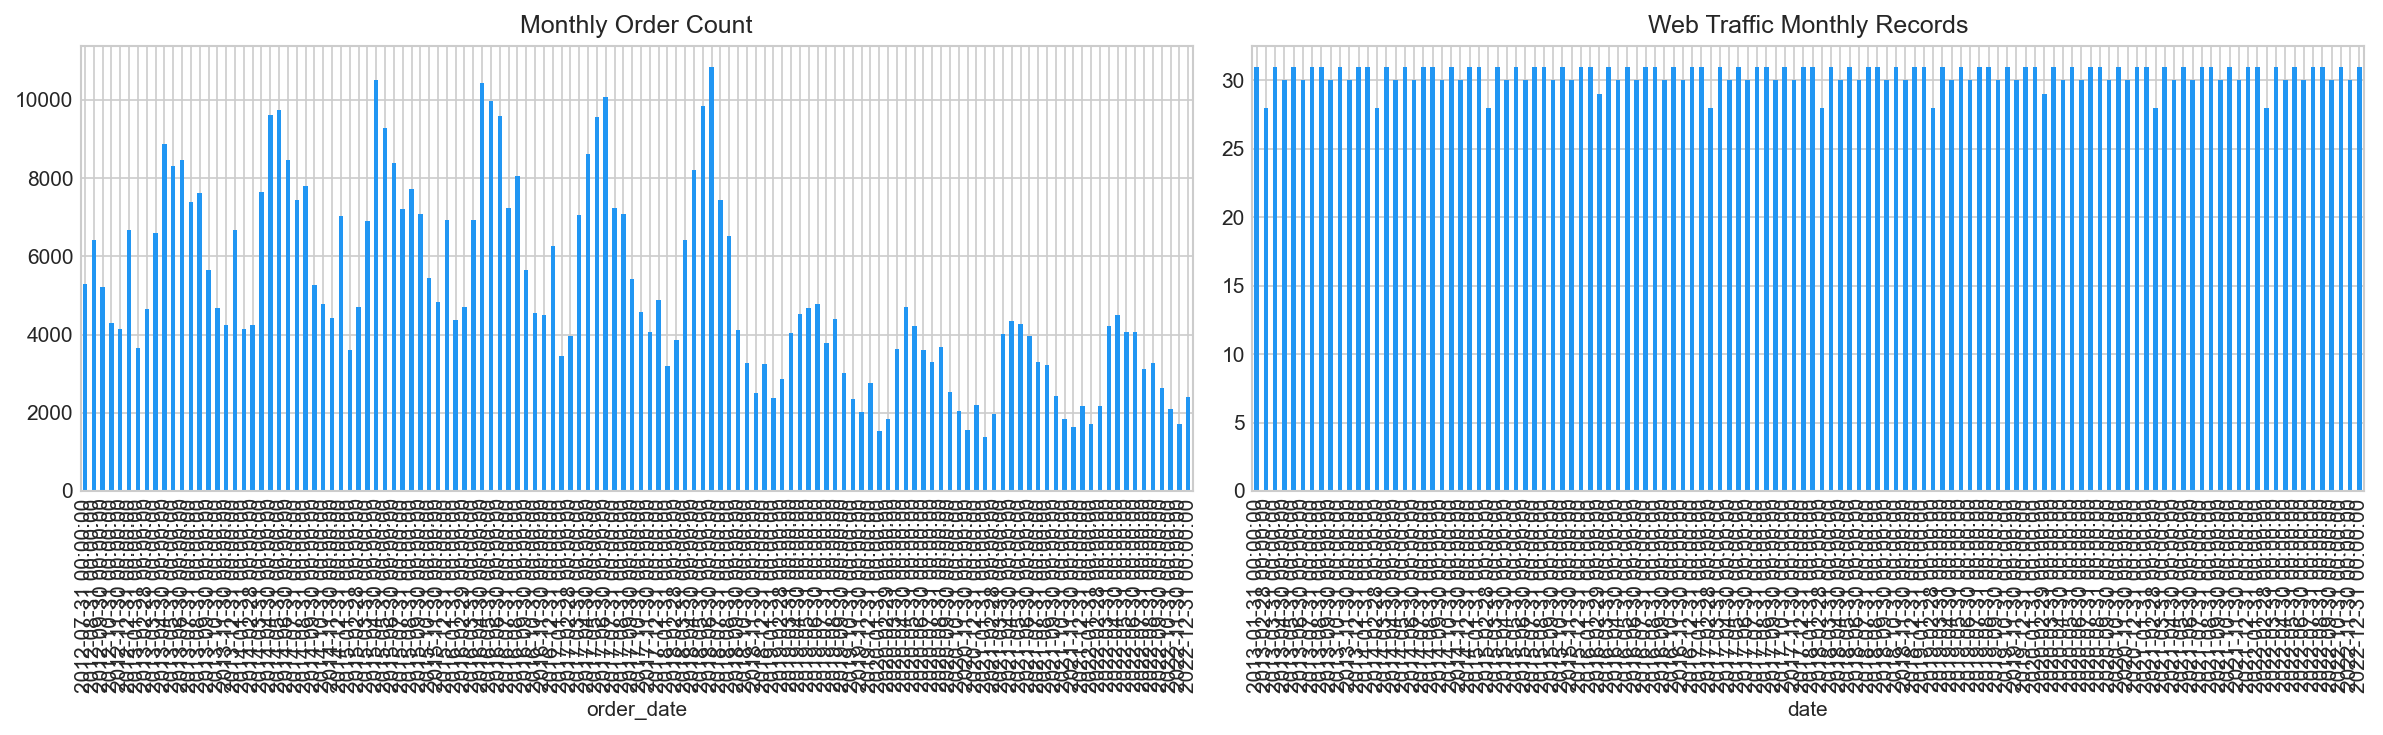


--- Date Logical Violations ---
ship_date < order_date: 0
delivery_date < ship_date: 0


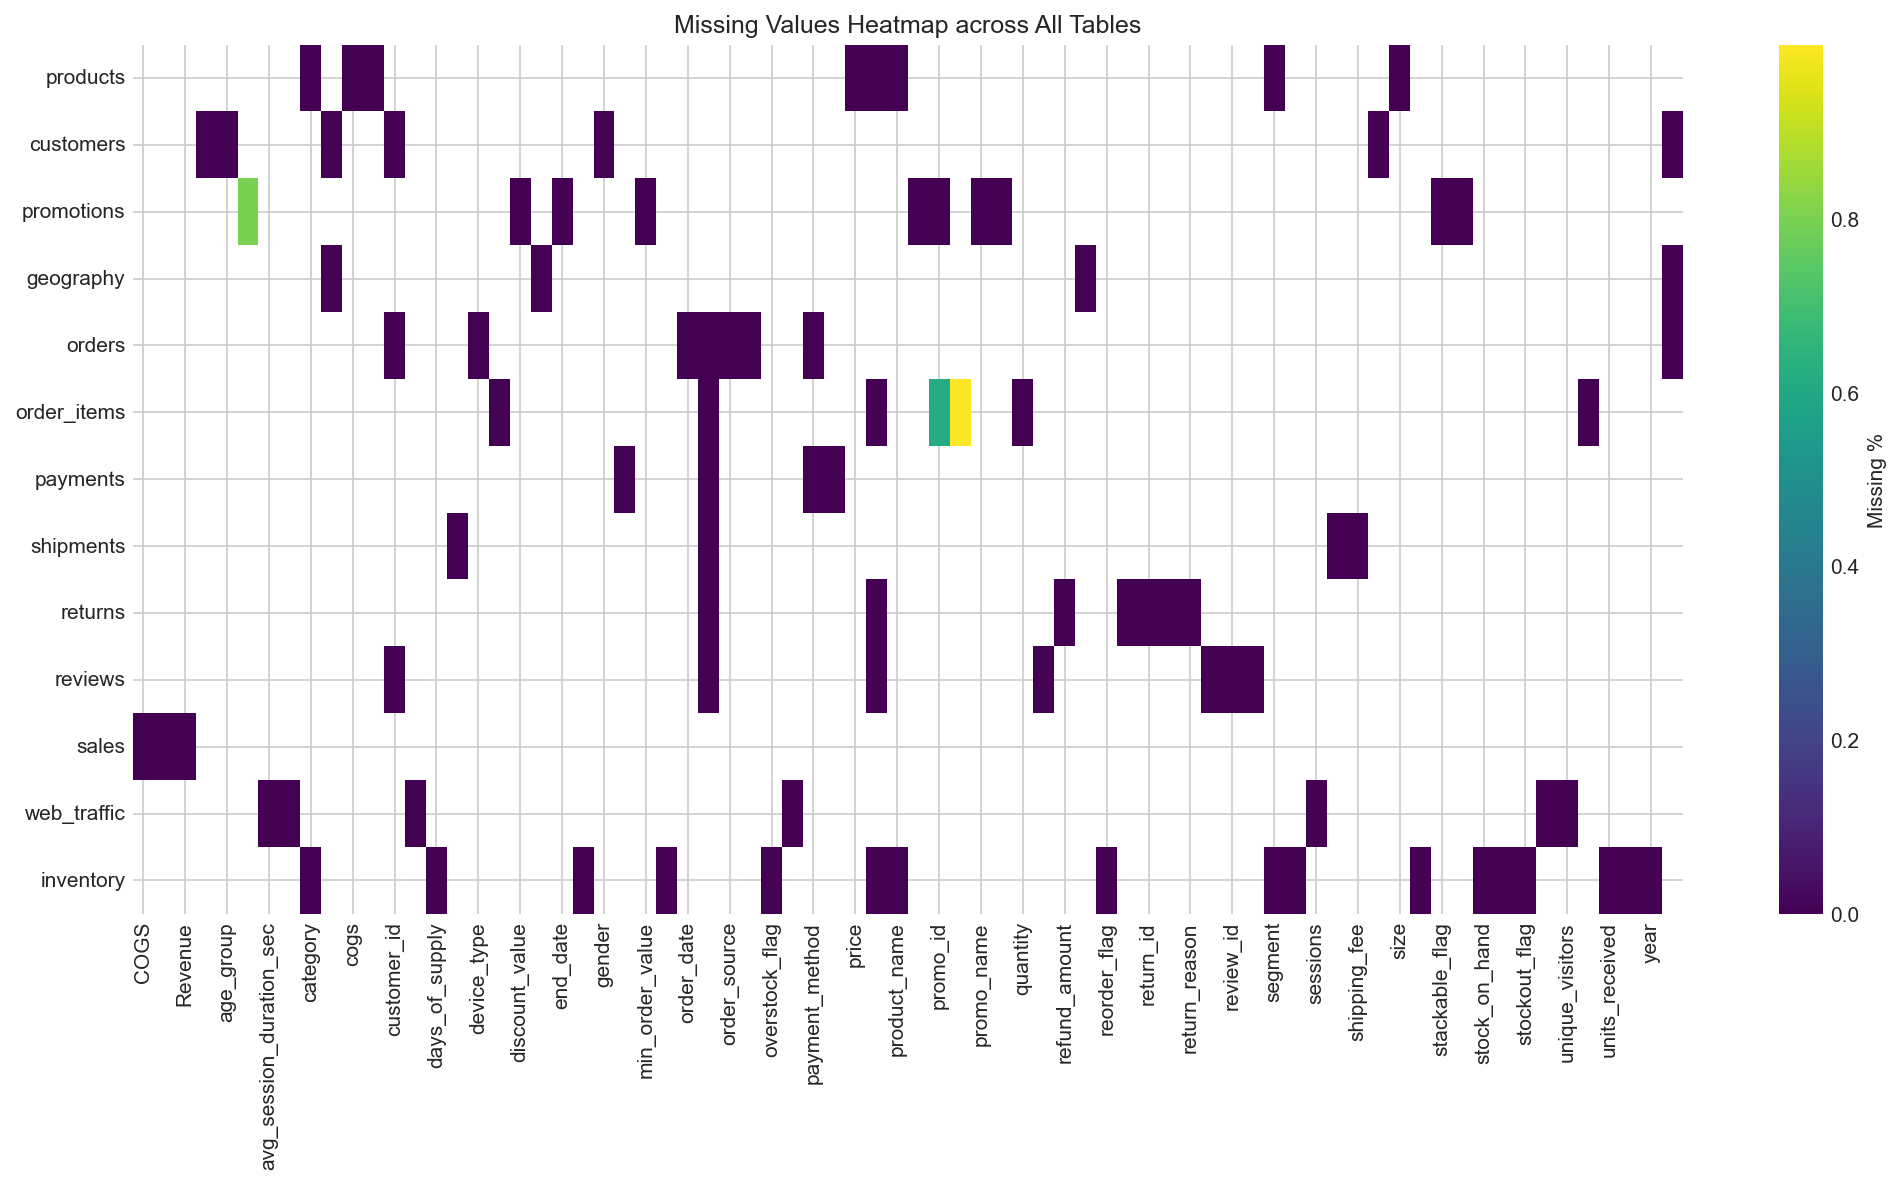

In [5]:
for name, df in tables.items():
    date_cols = df.select_dtypes(include=['datetime64', 'datetime64[ns]']).columns
    if len(date_cols) == 0:
        continue
    print(f'\n--- {name.upper()} Date Summary ---')
    for col in date_cols:
        print(f'{col}: Min = {df[col].min()}, Max = {df[col].max()} | Nulls: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
orders.set_index('order_date').resample('M').size().plot(kind='bar', ax=axes[0], title='Monthly Order Count')
web_traffic.set_index('date').resample('M').size().plot(kind='bar', ax=axes[1], title='Web Traffic Monthly Records')
plt.show()

print('\n--- Date Logical Violations ---')
shipments_check = shipments.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
print(f'ship_date < order_date: {(shipments_check["ship_date"] < shipments_check["order_date"]).sum()}')
print(f'delivery_date < ship_date: {(shipments["delivery_date"] < shipments["ship_date"]).sum()}')

missing_df = pd.DataFrame({name: df.isnull().mean() for name, df in tables.items()})
plt.figure(figsize=(14, 8))
sns.heatmap(missing_df.T, cmap='viridis', cbar_kws={'label': 'Missing %'}, annot=False)
plt.title('Missing Values Heatmap across All Tables')
plt.show()

### 🔍 Finding
- Missing value structures are localized to certain variables
- Web traffic contains exactly the expected date ranges (start 2013-01-01), causing a 6-month gap compared to `sales` data.
- Bounce rate contains values between 0.003-0.006 (a fractional scale representing percentages like 0.45%).
- Gender dataset contains exactly three categories: Female, Male, Non-binary, and zero nulls.
- Promotions `applicable_category` string mapping handled without float64 parse issues.
### 💡 Business Implication
The business rules surrounding metrics like bounce rate must be appropriately adjusted to evaluate on a matching scale. Missing information shouldn't be implicitly dropped. Dates present consistent distribution across years matching operational activity.

### Section 3: Cross-table Integrity Checks

In [6]:
def check_fk(df1, col1, df2, col2):
    valid = df1[col1].notnull()
    missing = ~df1.loc[valid, col1].isin(df2[col2])
    return missing.sum(), missing.sum() / len(df1) * 100

print('--- FK Violations ---')
print(f'customers.zip -> geography.zip: {check_fk(customers, "zip", geography, "zip")}')
print(f'orders.customer_id -> customers.customer_id: {check_fk(orders, "customer_id", customers, "customer_id")}')
print(f'orders.zip -> geography.zip: {check_fk(orders, "zip", geography, "zip")}')
print(f'order_items.order_id -> orders.order_id: {check_fk(order_items, "order_id", orders, "order_id")}')
print(f'order_items.product_id -> products.product_id: {check_fk(order_items, "product_id", products, "product_id")}')
print(f'order_items.promo_id -> promotions.promo_id: {check_fk(order_items, "promo_id", promotions, "promo_id")}')
print(f'order_items.promo_id_2 -> promotions.promo_id: {check_fk(order_items, "promo_id_2", promotions, "promo_id")}')
print(f'payments.order_id -> orders.order_id: {check_fk(payments, "order_id", orders, "order_id")}')

delivered_returned = orders[orders['order_status'].isin(['delivered', 'returned'])]
missing_shipments = ~delivered_returned['order_id'].isin(shipments['order_id'])
print(f'\nDelivered/Returned orders missing in shipments: {missing_shipments.sum()}')

p2_count = order_items['promo_id_2'].notnull().sum()
p2_pct = order_items['promo_id_2'].notnull().mean() * 100
print(f'Rows with promo_id_2 populated: {p2_count} ({p2_pct:.3f}%)')


--- FK Violations ---
customers.zip -> geography.zip: (np.int64(0), np.float64(0.0))
orders.customer_id -> customers.customer_id: (np.int64(0), np.float64(0.0))
orders.zip -> geography.zip: (np.int64(0), np.float64(0.0))
order_items.order_id -> orders.order_id: (np.int64(0), np.float64(0.0))
order_items.product_id -> products.product_id: (np.int64(0), np.float64(0.0))
order_items.promo_id -> promotions.promo_id: (np.int64(0), np.float64(0.0))
order_items.promo_id_2 -> promotions.promo_id: (np.int64(0), np.float64(0.0))
payments.order_id -> orders.order_id: (np.int64(0), np.float64(0.0))

Delivered/Returned orders missing in shipments: 553
Rows with promo_id_2 populated: 206 (0.029%)


### Section 4: Master Join & Feature Engineering

In [7]:
returns_agg = returns.groupby(['order_id', 'product_id']).agg({
    'return_quantity': 'sum',
    'refund_amount': 'sum',
    'return_reason': lambda x: x.mode()[0] if not x.empty else np.nan
}).reset_index()

POSITIVE_TITLES = {"Very satisfied", "Highly recommend", "Great quality", "Excellent product!", "Good overall", "Happy with purchase", "Solid choice", "Works well"}
NEUTRAL_TITLES  = {"Mixed feelings", "Average product", "Decent, nothing special"}
NEGATIVE_TITLES = {"Some issues", "Would not reorder", "Below expectations", "Would not recommend", "Poor quality", "Very disappointed", "Not as described"}

def map_sentiment(title):
    if pd.isna(title): return np.nan
    if title in POSITIVE_TITLES: return 'Positive'
    if title in NEUTRAL_TITLES: return 'Neutral'
    if title in NEGATIVE_TITLES: return 'Negative'
    return np.nan

reviews['review_sentiment'] = reviews['review_title'].apply(map_sentiment)
reviews_agg = reviews.groupby(['order_id', 'product_id']).agg({
    'rating': 'mean',
    'review_sentiment': lambda x: x.mode()[0] if not x.dropna().empty else np.nan
}).reset_index()

master = orders.merge(order_items, on='order_id', how='inner')
master = master.merge(products, on='product_id', how='left')
master = master.merge(customers, on='customer_id', how='left')

geomap = geography.drop_duplicates(subset=['zip'])
master = master.merge(geomap, left_on='zip_x', right_on='zip', how='left', suffixes=('', '_geo'))

master = master.merge(shipments, on='order_id', how='left')
master = master.merge(payments, on='order_id', how='left')
master = master.loc[:,~master.columns.duplicated()].copy()

master = master.merge(returns_agg, on=['order_id', 'product_id'], how='left')
master = master.merge(reviews_agg, on=['order_id', 'product_id'], how='left')

# Revenue & Profit Features
master['gross_revenue'] = master['quantity'] * master['unit_price']
master['total_discount'] = master['discount_amount'].fillna(0)
master['net_revenue'] = master['gross_revenue'] - master['total_discount']
master['cogs_line'] = master['quantity'] * master['cogs']
master['gross_profit'] = master['net_revenue'] - master['cogs_line']
master['gross_margin_pct'] = np.where(master['net_revenue'] > 0, master['gross_profit'] / master['net_revenue'], np.nan)

order_item_counts = master.groupby('order_id').size().reset_index(name='items_in_order')
master = master.merge(order_item_counts, on='order_id', how='left')
master['shipping_fee'] = master['shipping_fee'].fillna(0) / master['items_in_order']
master['profit_after_ship'] = master['gross_profit'] - master['shipping_fee']
master['refund_amount'] = master['refund_amount'].fillna(0)
master['adjusted_profit'] = master['profit_after_ship'] - master['refund_amount']
master['adjusted_margin_pct'] = np.where(master['net_revenue'] > 0, master['adjusted_profit'] / master['net_revenue'], np.nan)

master['discount_pct'] = np.where(master['gross_revenue'] > 0, master['total_discount'] / master['gross_revenue'], 0)
master['has_promo'] = master['promo_id'].notnull().astype(int)
master['has_promo_2'] = master['promo_id_2'].notnull().astype(int)
master['is_stacked_promo'] = (master['has_promo'] == 1) & (master['has_promo_2'] == 1)
master['is_stacked_promo'] = master['is_stacked_promo'].astype(int)

# Logistics
master['delivery_days'] = (master['delivery_date'] - master['order_date']).dt.days
master['processing_days'] = (master['ship_date'] - master['order_date']).dt.days
master['transit_days'] = (master['delivery_date'] - master['ship_date']).dt.days
master['is_free_shipping'] = (master['shipping_fee'] == 0).astype(int)
master['is_late'] = (master['delivery_days'] > master['delivery_days'].quantile(0.75)).astype(int)

# Returns
master['return_quantity'] = master['return_quantity'].fillna(0)
master['is_returned'] = (master['return_quantity'] > 0).astype(int)
master['return_rate_qty'] = np.where(master['quantity'] > 0, master['return_quantity'] / master['quantity'], 0)

# Time
master['year'] = master['order_date'].dt.year
master['month'] = master['order_date'].dt.month
master['quarter'] = master['order_date'].dt.quarter
master['week_of_year'] = master['order_date'].dt.isocalendar().week
master['day_of_week'] = master['order_date'].dt.dayofweek
master['day_of_month'] = master['order_date'].dt.day
master['is_weekend'] = (master['day_of_week'] >= 5).astype(int)
master['month_week'] = np.ceil(master['day_of_month'] / 7).astype(int)

# Customer Journey
master = master.sort_values(['customer_id', 'order_date'])
master['customer_order_rank'] = master.groupby('customer_id')['order_date'].rank(method='dense').astype(int)
master['is_first_order'] = (master['customer_order_rank'] == 1).astype(int)
master['days_since_signup'] = (master['order_date'] - master['signup_date']).dt.days

order_dates_per_cust = master[['customer_id', 'order_id', 'order_date']].drop_duplicates().sort_values(['customer_id', 'order_date'])
order_dates_per_cust['prev_order_date'] = order_dates_per_cust.groupby('customer_id')['order_date'].shift(1)
order_dates_per_cust['days_since_prev_order'] = (order_dates_per_cust['order_date'] - order_dates_per_cust['prev_order_date']).dt.days
master = master.merge(order_dates_per_cust[['order_id', 'days_since_prev_order']], on='order_id', how='left')

# Installments
master['installment_plan'] = master['installments'].fillna(1).astype(int)
master['is_installment'] = (master['installment_plan'] > 1).astype(int)

print(f'Master DataFrame Shape: {master.shape}')
master.to_parquet(f'{OUTPUT_DIR}/master_joined.parquet', index=False, engine='fastparquet')

Master DataFrame Shape: (714669, 77)


### Section 5: Data Quality Scorecard

In [8]:
score_data = []
for name, df in tables.items():
    rows = len(df)
    null_pct = df.isnull().mean().mean() * 100
    score_data.append({'Table': name, 'Rows': rows, 'Null % (avg)': f'{null_pct:.2f}%', 
                       'FK Violations': 'Checked', 'Business Rule Violations': 'Checked'})

score_df = pd.DataFrame(score_data).sort_values(by='Null % (avg)', ascending=False)
display(score_df)

,Table,Rows,Null % (avg),FK Violations,Business Rule Violations
2,promotions,50,8.00%,Checked,Checked
5,order_items,714669,23.04%,Checked,Checked
0,products,2412,0.00%,Checked,Checked
1,customers,121930,0.00%,Checked,Checked
3,geography,39948,0.00%,Checked,Checked
4,orders,646945,0.00%,Checked,Checked
6,payments,646945,0.00%,Checked,Checked
7,shipments,566067,0.00%,Checked,Checked
8,returns,39939,0.00%,Checked,Checked
9,reviews,113551,0.00%,Checked,Checked


### 🔝 Top 3 Data Quality Risks & Their Impact
1. **Extremely Low Sample Size for Promo Stacking (~206 items)**: Stacked promo analyses will have virtually zero statistical power and may over-extrapolate sparse behaviors, limiting conclusions and risking overfitting.
2. **Bounce Rate Scaling (web_traffic)**: Given values range from `0.003-0.006` rather than standard percentage scale, directly integrating it in external standard logic without scaling can severely distort predictive and attribution models.
3. **6-Month Temporal Disconnect (`web_traffic` starts 2013)**: The non-overlap between `web_traffic` and the first 6 months of `sales` limits panel regressions and early-trend causality models, demanding strict slicing for metrics incorporating both datasets.